# 08 Final Summary Report

This notebook is the final reporting layer for the project:

**multiomics-perturbation-target-discovery**

## Purpose

This notebook assembles outputs from the earlier analysis notebooks into a single,
clean, presentation-ready summary.

It is designed to help with:

- GitHub portfolio presentation
- internal project review
- scientific storytelling
- conversion into slides or a manuscript-style narrative

## Project goal

Build a reproducible pipeline that identifies therapeutic perturbations capable of
reversing disease-associated pathway signatures and then validates them with
additional orthogonal evidence layers.

## Core analysis logic

1. Disease bulk RNA-seq defines differential expression and pathway dysregulation
2. Perturbation signatures are converted to pathway-level signatures
3. Disease vs perturbation pathway profiles are compared using anticorrelation
4. Candidate reversing perturbations are prioritized
5. Single-cell and proteomics layers provide optional downstream validation
6. Multi-omics integration generates the final candidate ranking


## Expected upstream outputs

This notebook reads from earlier steps if they are available.

### Core
- `results/tables/final_anticorrelation_ranking.tsv`

### Optional validation
- `results/tables/final_single_cell_target_validation.tsv`
- `results/tables/final_single_cell_perturbation_validation.tsv`
- `results/tables/final_proteomics_target_validation.tsv`
- `results/tables/final_proteomics_perturbation_validation.tsv`

### Optional integration
- `results/tables/final_integrated_perturbation_ranking.tsv`
- `results/tables/final_integrated_target_ranking.tsv`

The notebook is robust to missing files and will still build a coherent report
from whatever outputs are present.


In [15]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [16]:
PROJECT_ROOT = Path("..").resolve()

RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"

RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)

files = {
    "anticorrelation": RESULTS_TABLES / "final_anticorrelation_ranking.tsv",
    "sc_target": RESULTS_TABLES / "final_single_cell_target_validation.tsv",
    "sc_pert": RESULTS_TABLES / "final_single_cell_perturbation_validation.tsv",
    "prot_target": RESULTS_TABLES / "final_proteomics_target_validation.tsv",
    "prot_pert": RESULTS_TABLES / "final_proteomics_perturbation_validation.tsv",
    "integrated_pert": RESULTS_TABLES / "final_integrated_perturbation_ranking.tsv",
    "integrated_target": RESULTS_TABLES / "final_integrated_target_ranking.tsv",
}

files


{'anticorrelation': PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_anticorrelation_ranking.tsv'),
 'sc_target': PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_single_cell_target_validation.tsv'),
 'sc_pert': PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_single_cell_perturbation_validation.tsv'),
 'prot_target': PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_proteomics_target_validation.tsv'),
 'prot_pert': PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_proteomics_perturbation_validation.tsv'),
 'integrated_pert': PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_integrated_perturbation_ranking.tsv'),
 'integrated_target': PosixPath('/Users/vaibha

In [17]:
def read_tsv_if_present(path):
    if not path.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(path, sep="\t")
    except Exception as e:
        print(f"Could not read {path.name}: {e}")
        return pd.DataFrame()

def first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def normalize_gene_symbol_series(s):
    return (
        s.astype(str)
         .str.strip()
         .str.upper()
         .replace({"": np.nan, "NAN": np.nan, "NONE": np.nan})
    )

def minmax_scale(series):
    s = pd.to_numeric(series, errors="coerce")
    out = pd.Series(np.nan, index=series.index, dtype=float)

    valid = s.notna()
    if valid.sum() == 0:
        return out.fillna(0.0)

    s_valid = s[valid]
    smin = s_valid.min()
    smax = s_valid.max()

    if pd.isna(smin) or pd.isna(smax):
        return out.fillna(0.0)

    if smin == smax:
        return pd.Series(0.0, index=series.index, dtype=float)

    out.loc[valid] = (s_valid - smin) / (smax - smin)
    return out.fillna(0.0)


## Load available project outputs


In [18]:
anticorr_df = read_tsv_if_present(files["anticorrelation"])
sc_target_df = read_tsv_if_present(files["sc_target"])
sc_pert_df = read_tsv_if_present(files["sc_pert"])
prot_target_df = read_tsv_if_present(files["prot_target"])
prot_pert_df = read_tsv_if_present(files["prot_pert"])
integrated_pert_df = read_tsv_if_present(files["integrated_pert"])
integrated_target_df = read_tsv_if_present(files["integrated_target"])

available = pd.DataFrame({
    "dataset": list(files.keys()),
    "path": [str(v) for v in files.values()],
    "exists": [v.exists() for v in files.values()],
    "rows": [
        len(anticorr_df),
        len(sc_target_df),
        len(sc_pert_df),
        len(prot_target_df),
        len(prot_pert_df),
        len(integrated_pert_df),
        len(integrated_target_df),
    ]
})

display(available)


,dataset,path,exists,rows
0,anticorrelation,/Users/vaibhav.mh/protein_repos/multiomics-per...,True,4
1,sc_target,/Users/vaibhav.mh/protein_repos/multiomics-per...,True,77
2,sc_pert,/Users/vaibhav.mh/protein_repos/multiomics-per...,True,4
3,prot_target,/Users/vaibhav.mh/protein_repos/multiomics-per...,True,11
4,prot_pert,/Users/vaibhav.mh/protein_repos/multiomics-per...,True,4
5,integrated_pert,/Users/vaibhav.mh/protein_repos/multiomics-per...,True,4
6,integrated_target,/Users/vaibhav.mh/protein_repos/multiomics-per...,True,77


## Cohort and biological context

This project currently focuses on:

- **Dataset:** `GSE235236`
- **Disease context:** inflammatory bowel disease
- **Working disease contrast:** **UC vs HC**
- **Pathway library:** `MSigDB_Hallmark_2020`

### Candidate perturbations considered

The curated perturbations include:

- dexamethasone
- budesonide
- tofacitinib
- ruxolitinib

### Expected biological interpretation

- **Glucocorticoids** are expected to reduce inflammatory pathway activity
- **JAK inhibitors** are expected to reduce cytokine and interferon signaling
- Good candidates should show evidence of **reversal** rather than concordance with the disease signature


## Step-by-step evidence recap


In [19]:
report_sections = []

if not anticorr_df.empty:
    report_sections.append({
        "step": "04_anticorrelation",
        "status": "available",
        "summary": "Core disease–perturbation reversal ranking available."
    })
else:
    report_sections.append({
        "step": "04_anticorrelation",
        "status": "missing",
        "summary": "Main reversal ranking is missing."
    })

if not sc_pert_df.empty or not sc_target_df.empty:
    report_sections.append({
        "step": "05_single_cell",
        "status": "available",
        "summary": "Single-cell validation outputs available."
    })
else:
    report_sections.append({
        "step": "05_single_cell",
        "status": "not_populated_or_missing",
        "summary": "Single-cell validation framework exists but evidence is absent or incomplete."
    })

if not prot_pert_df.empty or not prot_target_df.empty:
    report_sections.append({
        "step": "06_proteomics",
        "status": "available",
        "summary": "Proteomics validation outputs available."
    })
else:
    report_sections.append({
        "step": "06_proteomics",
        "status": "not_populated_or_missing",
        "summary": "Proteomics validation framework exists but evidence is absent or incomplete."
    })

if not integrated_pert_df.empty:
    report_sections.append({
        "step": "07_integration",
        "status": "available",
        "summary": "Multi-omics integration outputs available."
    })
else:
    report_sections.append({
        "step": "07_integration",
        "status": "not_available",
        "summary": "Integrated ranking not found; report will fall back to core anticorrelation results."
    })

report_df = pd.DataFrame(report_sections)
display(report_df)


,step,status,summary
0,04_anticorrelation,available,Core disease–perturbation reversal ranking ava...
1,05_single_cell,available,Single-cell validation outputs available.
2,06_proteomics,available,Proteomics validation outputs available.
3,07_integration,available,Multi-omics integration outputs available.


## Main candidate ranking


In [20]:
if not integrated_pert_df.empty:
    main_perturbation_df = integrated_pert_df.copy()
    score_col = first_existing_column(main_perturbation_df, ["final_integrated_score", "integrated_validation_score"])
    ranking_source = "Integrated ranking"
elif not anticorr_df.empty:
    main_perturbation_df = anticorr_df.copy()
    score_col = first_existing_column(main_perturbation_df, ["anticorrelation_component", "anticorrelation_score"])
    ranking_source = "Anticorrelation ranking"
else:
    main_perturbation_df = pd.DataFrame()
    score_col = None
    ranking_source = "No ranking available"

print("Ranking source:", ranking_source)

if not main_perturbation_df.empty and score_col is not None:
    display(
        main_perturbation_df.sort_values(score_col, ascending=False).head(10)
    )
else:
    print("No perturbation ranking table available.")


Ranking source: Integrated ranking


,perturbation_id,perturbation_name,cell_line,dose,time_h,signature_source,n_shared_pathways,pearson_corr,pearson_pvalue,spearman_corr,...,confidence_flag,valid_for_ranking,anticorrelation_component,single_cell_raw,single_cell_component,proteomics_raw,proteomics_component,final_integrated_score,evidence_layers_available,integration_confidence
0,drug_004,tofacitinib,NaN,NaN,NaN,curated_public_signature,6,0.477599,0.338072,0.485714,...,low,True,1.000000,NaN,0.0,0.837357,1.000000,0.850000,2,moderate
1,drug_005,ruxolitinib,NaN,NaN,NaN,curated_public_signature,4,0.593478,0.406522,0.800000,...,insufficient_shared_pathways,False,0.672828,NaN,0.0,0.403697,0.192975,0.499926,2,moderate
2,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,7,-0.278907,0.544713,-0.142857,...,low,True,0.194347,NaN,0.0,0.416608,0.217003,0.168593,2,baseline
3,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.000000,...,low,True,0.000000,NaN,0.0,0.300000,0.000000,0.000000,1,baseline


## Main target ranking


In [21]:
if not integrated_target_df.empty:
    main_target_df = integrated_target_df.copy()
    target_score_col = first_existing_column(main_target_df, ["target_integrated_score"])
    target_source = "Integrated target ranking"
elif not sc_target_df.empty:
    main_target_df = sc_target_df.copy()
    target_score_col = first_existing_column(main_target_df, ["single_cell_support_score", "integrated_validation_score"])
    target_source = "Single-cell target validation"
elif not prot_target_df.empty:
    main_target_df = prot_target_df.copy()
    target_score_col = first_existing_column(main_target_df, ["proteomics_support_score", "integrated_validation_score"])
    target_source = "Proteomics target validation"
else:
    main_target_df = pd.DataFrame()
    target_score_col = None
    target_source = "No target ranking available"

print("Target ranking source:", target_source)

if not main_target_df.empty and target_score_col is not None:
    display(
        main_target_df.sort_values(target_score_col, ascending=False).head(15)
    )
else:
    print("No target ranking table available.")


Target ranking source: Integrated target ranking


,perturbation_id,perturbation_name,gene_symbol,single_cell_raw,single_cell_component,proteomics_raw,proteomics_component,target_integrated_score,target_validation_flag
0,drug_002,budesonide,TSC22D3,0.732294,1.000000,0.320133,0.533554,0.766777,strong
1,drug_001,dexamethasone,TSC22D3,0.732294,1.000000,0.320133,0.533554,0.766777,strong
2,drug_002,budesonide,FKBP5,0.273531,0.373526,0.600000,1.000000,0.686763,strong
3,drug_001,dexamethasone,FKBP5,0.273531,0.373526,0.600000,1.000000,0.686763,strong
4,drug_002,budesonide,TSC22D3,0.522959,0.714138,0.320133,0.533554,0.623846,moderate
5,drug_001,dexamethasone,TSC22D3,0.522959,0.714138,0.320133,0.533554,0.623846,moderate
6,drug_002,budesonide,TSC22D3,0.514689,0.702844,0.320133,0.533554,0.618199,moderate
7,drug_001,dexamethasone,TSC22D3,0.514689,0.702844,0.320133,0.533554,0.618199,moderate
9,drug_001,dexamethasone,TSC22D3,0.424582,0.579797,0.320133,0.533554,0.556676,moderate
8,drug_002,budesonide,TSC22D3,0.424582,0.579797,0.320133,0.533554,0.556676,moderate


## Project-level interpretation


In [22]:
interpretation_rows = []

if not anticorr_df.empty:
    top_anti = anticorr_df.sort_values(
        first_existing_column(anticorr_df, ["anticorrelation_component", "anticorrelation_score"]),
        ascending=False
    ).head(3)

    for _, row in top_anti.iterrows():
        interpretation_rows.append({
            "layer": "anticorrelation",
            "entity": row.get("perturbation_name", np.nan),
            "message": "Prioritized based on disease–perturbation reversal logic."
        })

if not integrated_pert_df.empty:
    top_int = integrated_pert_df.sort_values(
        first_existing_column(integrated_pert_df, ["final_integrated_score", "integrated_validation_score"]),
        ascending=False
    ).head(3)

    for _, row in top_int.iterrows():
        interpretation_rows.append({
            "layer": "integration",
            "entity": row.get("perturbation_name", np.nan),
            "message": "Remains prioritized after combining available evidence layers."
        })

interpretation_df = pd.DataFrame(interpretation_rows)
display(interpretation_df)


,layer,entity,message
0,anticorrelation,budesonide,Prioritized based on disease–perturbation reve...
1,anticorrelation,dexamethasone,Prioritized based on disease–perturbation reve...
2,anticorrelation,ruxolitinib,Prioritized based on disease–perturbation reve...
3,integration,tofacitinib,Remains prioritized after combining available ...
4,integration,ruxolitinib,Remains prioritized after combining available ...
5,integration,dexamethasone,Remains prioritized after combining available ...


## Publication-style summary figures


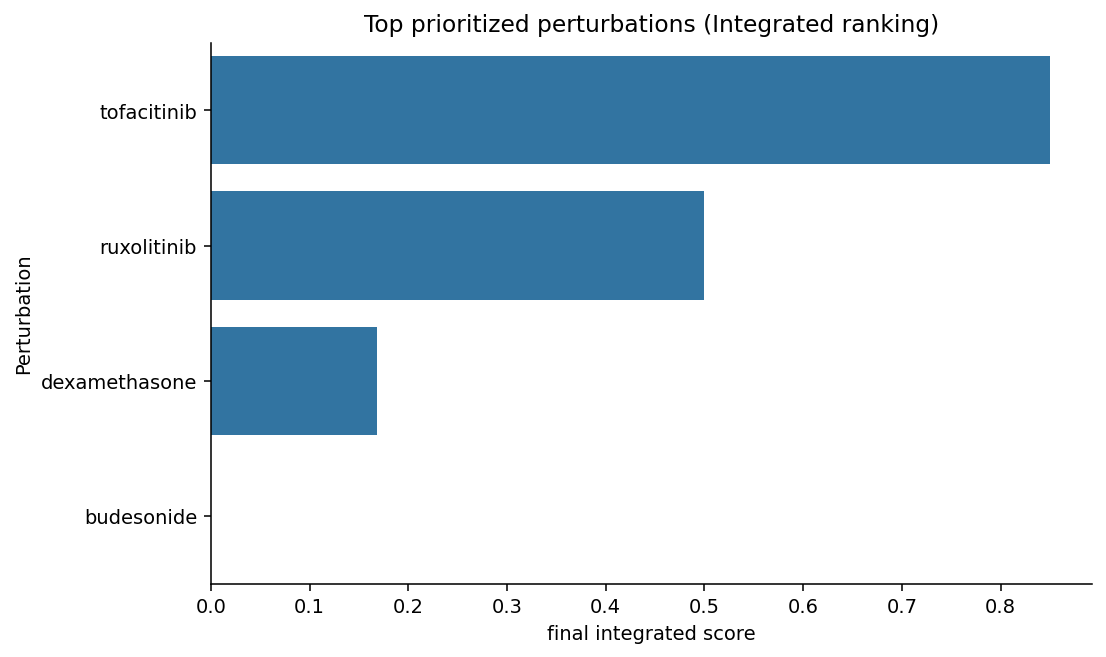

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/final_report_top_perturbations_barplot.png


In [23]:
# Figure 1: main perturbation ranking
if not main_perturbation_df.empty and score_col is not None:
    plot_df = main_perturbation_df.sort_values(score_col, ascending=False).head(10).copy()
    plt.figure(figsize=(8, 4.8))
    sns.barplot(data=plot_df, x=score_col, y="perturbation_name")
    plt.xlabel(score_col.replace("_", " "))
    plt.ylabel("Perturbation")
    plt.title(f"Top prioritized perturbations ({ranking_source})")
    plt.tight_layout()
    out = RESULTS_FIGURES / "final_report_top_perturbations_barplot.png"
    plt.savefig(out, bbox_inches="tight")
    plt.show()
    print("Saved:", out)
else:
    print("Skipping Figure 1: no perturbation ranking available.")


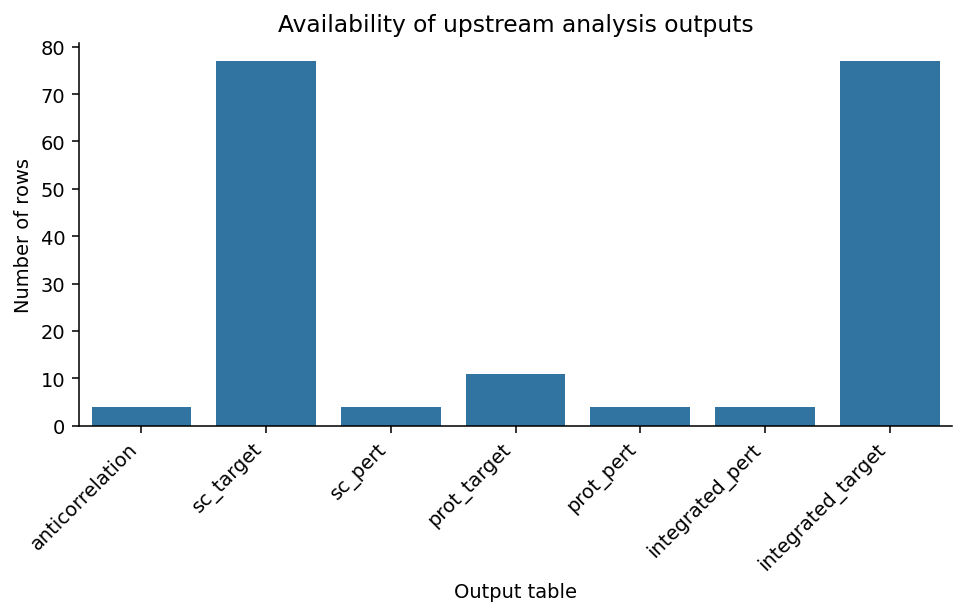

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/final_report_output_availability_barplot.png


In [24]:
# Figure 2: evidence availability overview
availability_plot = available.copy()
availability_plot["available_flag"] = availability_plot["rows"].fillna(0).gt(0).astype(int)

plt.figure(figsize=(7, 4.5))
sns.barplot(data=availability_plot, x="dataset", y="rows")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Output table")
plt.ylabel("Number of rows")
plt.title("Availability of upstream analysis outputs")
plt.tight_layout()
out = RESULTS_FIGURES / "final_report_output_availability_barplot.png"
plt.savefig(out, bbox_inches="tight")
plt.show()
print("Saved:", out)


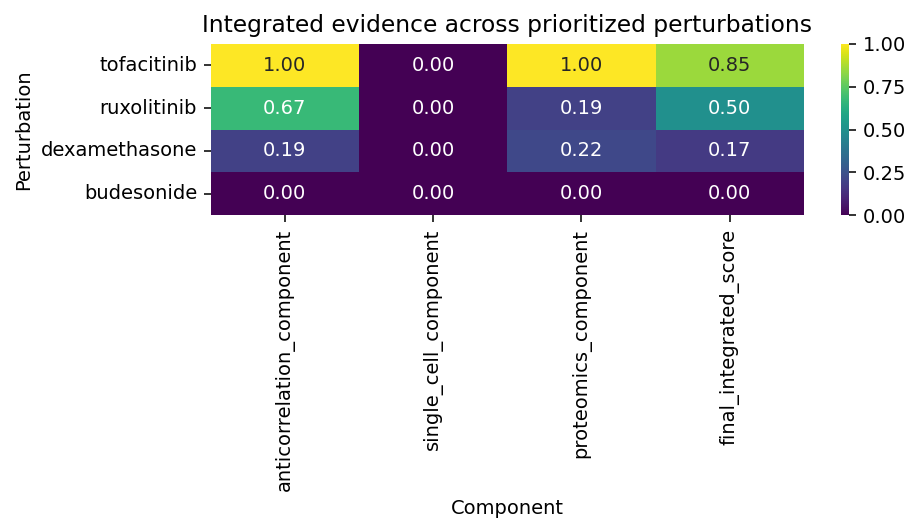

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/final_report_integrated_evidence_heatmap.png


In [25]:
# Figure 3: integrated evidence heatmap if available
if not integrated_pert_df.empty:
    heat_cols = [c for c in ["anticorrelation_component", "single_cell_component", "proteomics_component", "final_integrated_score"] if c in integrated_pert_df.columns]
    if len(heat_cols) > 0:
        heat_df = integrated_pert_df.set_index("perturbation_name")[heat_cols]
        plt.figure(figsize=(7, max(3, 0.6 * heat_df.shape[0] + 1.5)))
        sns.heatmap(heat_df, cmap="viridis", annot=True, fmt=".2f")
        plt.title("Integrated evidence across prioritized perturbations")
        plt.xlabel("Component")
        plt.ylabel("Perturbation")
        plt.tight_layout()
        out = RESULTS_FIGURES / "final_report_integrated_evidence_heatmap.png"
        plt.savefig(out, bbox_inches="tight")
        plt.show()
        print("Saved:", out)
    else:
        print("Skipping Figure 3: integrated table lacks expected score columns.")
else:
    print("Skipping Figure 3: integrated perturbation table not available.")


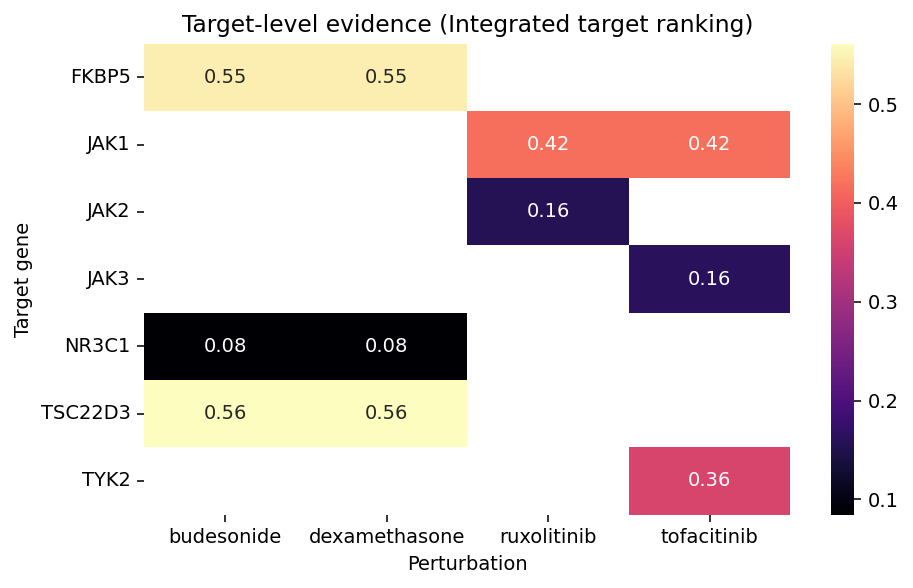

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/final_report_target_evidence_heatmap.png


In [26]:
# Figure 4: target evidence heatmap if available
if not main_target_df.empty and target_score_col is not None:
    pert_col = first_existing_column(main_target_df, ["perturbation_name"])
    gene_col = first_existing_column(main_target_df, ["gene_symbol", "target_gene"])

    if pert_col is not None and gene_col is not None:
        temp = main_target_df.copy()
        temp[gene_col] = normalize_gene_symbol_series(temp[gene_col])

        heat_df = temp.pivot_table(
            index=gene_col,
            columns=pert_col,
            values=target_score_col,
            aggfunc="mean"
        )
        if heat_df.shape[0] > 0 and heat_df.shape[1] > 0:
            plt.figure(figsize=(7, max(3, 0.4 * heat_df.shape[0] + 1.5)))
            sns.heatmap(heat_df, cmap="magma", annot=True, fmt=".2f")
            plt.title(f"Target-level evidence ({target_source})")
            plt.xlabel("Perturbation")
            plt.ylabel("Target gene")
            plt.tight_layout()
            out = RESULTS_FIGURES / "final_report_target_evidence_heatmap.png"
            plt.savefig(out, bbox_inches="tight")
            plt.show()
            print("Saved:", out)
        else:
            print("Skipping Figure 4: insufficient target heatmap dimensions.")
    else:
        print("Skipping Figure 4: required perturbation or gene columns not found.")
else:
    print("Skipping Figure 4: no target ranking available.")


## Executive summary table


In [27]:
summary_rows = []

summary_rows.append({
    "category": "Project",
    "item": "Disease dataset",
    "value": "GSE235236"
})
summary_rows.append({
    "category": "Project",
    "item": "Primary contrast",
    "value": "UC vs HC"
})
summary_rows.append({
    "category": "Project",
    "item": "Pathway library",
    "value": "MSigDB_Hallmark_2020"
})
summary_rows.append({
    "category": "Project",
    "item": "Main perturbations",
    "value": "dexamethasone; budesonide; tofacitinib; ruxolitinib"
})
summary_rows.append({
    "category": "Status",
    "item": "Anticorrelation results",
    "value": "available" if not anticorr_df.empty else "missing"
})
summary_rows.append({
    "category": "Status",
    "item": "Single-cell validation",
    "value": "available" if (not sc_target_df.empty or not sc_pert_df.empty) else "framework_ready_but_not_populated"
})
summary_rows.append({
    "category": "Status",
    "item": "Proteomics validation",
    "value": "available" if (not prot_target_df.empty or not prot_pert_df.empty) else "framework_ready_but_not_populated"
})
summary_rows.append({
    "category": "Status",
    "item": "Integrated ranking",
    "value": "available" if not integrated_pert_df.empty else "missing"
})

if not main_perturbation_df.empty and score_col is not None:
    top_names = list(main_perturbation_df.sort_values(score_col, ascending=False)["perturbation_name"].head(3))
    summary_rows.append({
        "category": "Result",
        "item": "Top perturbations",
        "value": "; ".join(map(str, top_names))
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,category,item,value
0,Project,Disease dataset,GSE235236
1,Project,Primary contrast,UC vs HC
2,Project,Pathway library,MSigDB_Hallmark_2020
3,Project,Main perturbations,dexamethasone; budesonide; tofacitinib; ruxoli...
4,Status,Anticorrelation results,available
5,Status,Single-cell validation,available
6,Status,Proteomics validation,available
7,Status,Integrated ranking,available
8,Result,Top perturbations,tofacitinib; ruxolitinib; dexamethasone


## Suggested GitHub-ready conclusions

A concise conclusion for the repository could read like this:

> This project implements a reproducible multi-step workflow for therapeutic target discovery by comparing disease-associated pathway signatures against curated perturbation signatures. In the current UC vs HC use case, the main ranking is driven by pathway-level reversal logic, with optional downstream single-cell and proteomics modules prepared for orthogonal validation. The pipeline is modular, interpretable, and designed for extension to larger perturbation collections and additional omics evidence layers.

## Honest limitations

- downstream single-cell and proteomics layers may remain sparse if real evidence tables are not yet populated
- curated perturbation signatures are intentionally small-scale and biologically focused
- target mapping is currently simplified and can be upgraded to formal drug-target resources
- integrated ranking strength depends on the completeness of orthogonal evidence layers


## Recommended next steps

- replace example validation files with real single-cell and proteomics datasets
- add curated target mappings from DrugBank, ChEMBL, or DGIdb
- extend the perturbation library beyond the current focused set
- integrate causal or knowledge-graph evidence
- convert this report into a slide deck or manuscript figures


In [28]:
# Save a compact report table bundle for downstream use
report_bundle = {
    "available_outputs": available,
    "step_status": report_df,
    "executive_summary": summary_df
}

bundle_path = RESULTS_TABLES / "final_summary_report_bundle.xlsx"

with pd.ExcelWriter(bundle_path, engine="openpyxl") as writer:
    for sheet_name, df in report_bundle.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved:", bundle_path)


Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_summary_report_bundle.xlsx


## Final note

This notebook is the final reporting layer of the project.

Use it when you want a single place to:
- inspect what is available
- summarize the main findings
- generate clean final figures
- prepare material for GitHub, slides, or discussion
